# Expectation, Variance, and Covariance

**Goal:** Understand expected value, variance, and covariance — the building blocks of statistical ML.

**Reference:** Mathematics for ML - Chapter 6.4


## Expected Value (Mean)

The **expected value** of a random variable is its long-run average:

**Discrete:**
$$\mathbb{E}[X] = \sum_x x \cdot p(x)$$

**Continuous:**
$$\mathbb{E}[X] = \int_{-\infty}^{\infty} x \cdot p(x) \, dx$$

**For a function of $X$:**
$$\mathbb{E}[g(X)] = \sum_x g(x) \cdot p(x)$$

**Key properties:**
- **Linearity:** $\mathbb{E}[aX + bY] = a\mathbb{E}[X] + b\mathbb{E}[Y]$
- This holds **always**, even if $X$ and $Y$ are dependent!
- $\mathbb{E}[c] = c$ for a constant

In [17]:
import numpy as np
import matplotlib.pyplot as plt


In [18]:
np.random.seed(42)
rolls = np.random.randint(1, 7, size=1_000_000)

print(f"E[X] empirical: {rolls.mean():.4f}")
print(f"E[X] theoretical: 3.5")

# Expected value of X^2
print(f"\nE[X^2] empirical: {(rolls ** 2).mean():.4f}")
print(f"E[X^2] theoretical: {(1 + 4 + 9 + 16 + 25 + 36) / 6:.4f}")

E[X] empirical: 3.5002
E[X] theoretical: 3.5

E[X^2] empirical: 15.1665
E[X^2] theoretical: 15.1667


## Variance

Variance measures **spread** around the mean:

$$\text{Var}(X) = \mathbb{E}\left[(X - \mathbb{E}[X])^2\right]$$

**Alternative formula:**
$$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$

**Properties:**
- $\text{Var}(c) = 0$ (constant has no spread)
- $\text{Var}(aX + b) = a^2 \text{Var}(X)$
- **Standard deviation:** $\sigma = \sqrt{\text{Var}(X)}$ (same units as X)

**Why it matters for ML:**
- Bias-variance tradeoff
- Feature scaling (standardization)
- Understanding uncertainty in predictions

In [19]:

var_empirical = (rolls ** 2).mean() - (rolls.mean()) ** 2
print(f"Var(X) empirical: {var_empirical:.4f}")
print(f"Var(X) theoretical: {91/6 - (7/2)**2:.4f}")

# numpy's built-in
print(f"np.var: {rolls.var():.4f}")

Var(X) empirical: 2.9151
Var(X) theoretical: 2.9167
np.var: 2.9151


## Covariance

Covariance measures how two variables **move together**:

$$\text{Cov}(X, Y) = \mathbb{E}\left[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])\right]$$

**Alternative formula:**
$$\text{Cov}(X, Y) = \mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y]$$

**Sign interpretation:**
- $\text{Cov} > 0$: X and Y tend to increase together
- $\text{Cov} < 0$: when X increases, Y tends to decrease
- $\text{Cov} = 0$: no linear relationship (uncorrelated)

**Important:** Covariance is **not** normalized, so its magnitude depends on units.

**Correlation** is the normalized version:
$$\rho_{XY} = \frac{\text{Cov}(X, Y)}{\sqrt{\text{Var}(X) \text{Var}(Y)}} \in [-1, 1]$$

In [20]:
np.random.seed(0)
N = 100_000

# Positive covariance
x = np.random.randn(N)
y_pos = 0.8 * x + 0.6 * np.random.randn(N)

# Negative covariance
y_neg = -0.8 * x + 0.6 * np.random.randn(N)

# Independent
y_ind = np.random.randn(N)

for name, y in [("positive", y_pos), ("negative", y_neg), ("independent", y_ind)]:
    cov = np.mean((x - x.mean()) * (y - y.mean()))
    corr = np.corrcoef(x, y)[0, 1]
    print(f"{name:12s}  Cov = {cov:+.4f}   Corr = {corr:+.4f}")

positive      Cov = +0.7962   Corr = +0.7998
negative      Cov = -0.7929   Corr = -0.7980
independent   Cov = +0.0040   Corr = +0.0040


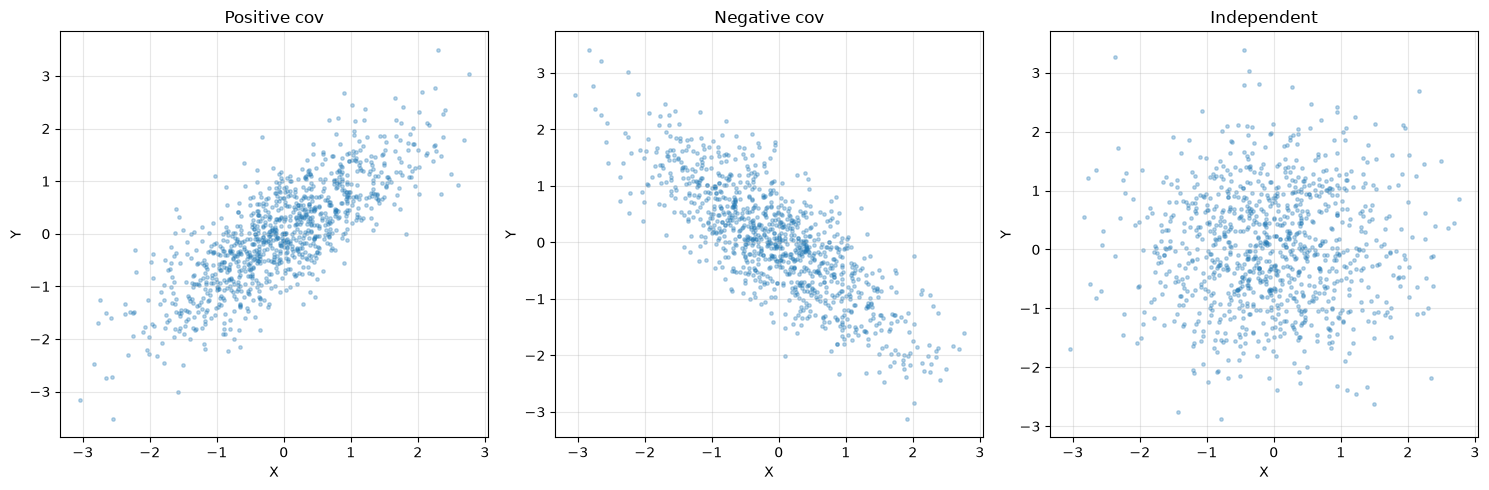

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

data = [
    ("Positive cov", x, y_pos),
    ("Negative cov", x, y_neg),
    ("Independent", x, y_ind),
]

for ax, (title, xs, ys) in zip(axes, data):
    ax.scatter(xs[:1000], ys[:1000], alpha=0.3, s=6)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3)
    corr = np.corrcoef(xs, ys)[0, 1]
    # ax.text(0.05, 0.95, f'ρ = {corr:.2f}', transform=ax.transAxes,
    #         verticalalignment='top', fontsize=12)

plt.tight_layout()
plt.show()

## Covariance Matrix

For a vector $\mathbf{x} \in \mathbb{R}^d$:

$$\Sigma = \mathbb{E}\left[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^T\right]$$

- Shape: $d \times d$, **symmetric**, **positive semi-definite**
- Diagonal entries: variances of each variable
- Off-diagonal: covariances between pairs

**This matrix is everywhere in ML:**
- PCA: eigenvectors of $\Sigma$ are the principal directions
- Gaussian: $\Sigma$ defines the shape of the distribution
- Whitening: transform data so $\Sigma = I$

In [22]:
# Generate 3D data
np.random.seed(42)
data = np.random.randn(1000, 3) @ np.array([
    [1.0, 0.5, 0.2],
    [0.0, 1.5, 0.3],
    [0.0, 0.0, 0.8],
])

# Covariance matrix
cov_matrix = np.cov(data.T)
print("Covariance matrix:")
print(cov_matrix)
print("\nShape:", cov_matrix.shape)
print("Symmetric?", np.allclose(cov_matrix, cov_matrix.T))

# Eigenvalues (variances along principal directions)
eigs = np.linalg.eigvalsh(cov_matrix)
print("\nEigenvalues:", eigs)
print("All non-negative?", np.all(eigs >= 0))

Covariance matrix:
[[0.94131191 0.40179892 0.15825139]
 [0.40179892 2.45520286 0.56441079]
 [0.15825139 0.56441079 0.74978152]]

Shape: (3, 3)
Symmetric? True

Eigenvalues: [0.57527684 0.8422921  2.72872734]
All non-negative? True


## Key Takeaways

- **Expectation:** long-run average, linear
- **Variance:** spread around mean, $\text{Var}(X) = \mathbb{E}[X^2] - \mathbb{E}[X]^2$
- **Covariance:** how two variables move together, sign matters
- **Correlation:** normalized covariance, always in $[-1, 1]$
- **Covariance matrix:** symmetric, positive semi-definite, diagonal = variances

## Connection to ML

- **Bias-variance tradeoff:** decompose error into bias² + variance + noise
- **Feature scaling:** standardize to mean 0, variance 1
- **PCA:** eigenvectors of covariance matrix = principal components
- **Whitening:** transform data to have identity covariance
- **Gaussian models:** defined by mean and covariance